# HDB Market Segmentation

Compare Town × Flat Type segments by historical activity, pricing, and 2025 versus 2024 momentum.

Executed using the supplied cleaned CSV. DATA_PATH points to the original source; exports are saved alongside this reviewed notebook. Adjust these paths if moving the notebook.


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data").is_dir() and (path / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the project directory.")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hdb_resale_clean.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Could not find data file: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)
required = ["month", "town", "flat_type", "resale_price", "price_per_sqm"]
missing = sorted(set(required) - set(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")
df["month"] = pd.to_datetime(df["month"], errors="raise")
df["year"] = df["month"].dt.year
if df[required].isna().any().any():
    raise ValueError("Required columns contain missing values. Review the cleaned dataset.")
for column in ["resale_price", "price_per_sqm"]:
    df[column] = pd.to_numeric(df[column], errors="raise")
    if not (np.isfinite(df[column]) & df[column].gt(0)).all():
        raise ValueError(f"{column} must contain finite positive values.")
keys = ["town", "flat_type"]


## 1. Date coverage

Twelve observed months are necessary for full-year comparisons; also confirm that the source extract is complete.

In [32]:
print("First month:", df["month"].min())
print("Last month:", df["month"].max())
coverage = df.groupby("year").agg(
    months_present=("month", lambda s: s.dt.to_period("M").nunique()),
    transactions=("resale_price", "size")
)
display(coverage)
comparison_coverage = coverage.reindex([2024, 2025])["months_present"]
if not comparison_coverage.eq(12).all():
    raise ValueError("2024 and 2025 must each contain all 12 months for this full-year comparison.")


First month: 2017-01-01 00:00:00
Last month: 2026-08-01 00:00:00


,months_present,transactions
year,,
2017,12,20509
2018,12,21561
2019,12,22186
2020,12,23333
2021,12,29087
2022,12,26720
2023,12,25754
2024,12,27832
2025,12,25085


## 2. Historical segment summary

All figures in this section cover the entire loaded dataset.

In [33]:
segment_summary = (
    df.groupby(["town", "flat_type"])
    .agg(
        transactions=("resale_price", "size"),
        median_resale_price=("resale_price", "median"),
        median_price_per_sqm=("price_per_sqm", "median"),
        total_transaction_value=("resale_price", "sum")
    )
    .reset_index()
)

segment_summary.head()

,town,flat_type,transactions,median_resale_price,median_price_per_sqm,total_transaction_value
0,ANG MO KIO,2 ROOM,179,265000.0,5840.910,4.702903e+07
1,ANG MO KIO,3 ROOM,5102,350000.0,4903.275,1.832567e+09
2,ANG MO KIO,4 ROOM,2798,515000.0,5543.480,1.596733e+09
3,ANG MO KIO,5 ROOM,1440,745000.0,6200.000,1.108615e+09
4,ANG MO KIO,EXECUTIVE,136,920000.0,5901.490,1.283341e+08


In [34]:
print("Segments:", len(segment_summary))
assert segment_summary["transactions"].sum() == len(df)
segment_summary["transactions"].describe()


Segments: 131


count     131.000000
mean     1826.946565
std      2044.096582
min         2.000000
25%       235.000000
50%      1063.000000
75%      2706.000000
max      9666.000000
Name: transactions, dtype: float64

## 3. Largest segments by historical transaction volume

In [35]:
top_volume_segments = (
    segment_summary
    .sort_values("transactions", ascending=False)
    .head(15)
)

top_volume_segments

,town,flat_type,transactions,median_resale_price,median_price_per_sqm,total_transaction_value
101,SENGKANG,4 ROOM,9666,503000.0,5434.780,4.995699e+09
86,PUNGGOL,4 ROOM,9170,530000.0,5706.520,4.991252e+09
127,YISHUN,4 ROOM,7913,448000.0,4782.610,3.569730e+09
122,WOODLANDS,4 ROOM,7715,443000.0,4611.110,3.432545e+09
111,TAMPINES,4 ROOM,6892,535000.0,5376.340,3.783768e+09
102,SENGKANG,5 ROOM,6592,568000.0,5044.250,3.809517e+09
67,JURONG WEST,4 ROOM,5878,450000.0,4575.470,2.651667e+09
57,HOUGANG,4 ROOM,5487,495000.0,5145.630,2.769118e+09
87,PUNGGOL,5 ROOM,5429,615000.0,5517.240,3.345052e+09
42,CHOA CHU KANG,4 ROOM,5215,470000.0,4722.220,2.377329e+09


## 4. Largest segments by historical transaction value

In [36]:
segment_summary["transaction_value_billion"] = segment_summary["total_transaction_value"] / 1_000_000_000
top_value_segments = segment_summary.sort_values("total_transaction_value", ascending=False).head(15)
top_value_segments[keys + ["transactions", "transaction_value_billion"]]


,town,flat_type,transactions,transaction_value_billion
101,SENGKANG,4 ROOM,9666,4.995699
86,PUNGGOL,4 ROOM,9170,4.991252
102,SENGKANG,5 ROOM,6592,3.809517
111,TAMPINES,4 ROOM,6892,3.783768
127,YISHUN,4 ROOM,7913,3.569730
122,WOODLANDS,4 ROOM,7715,3.432545
87,PUNGGOL,5 ROOM,5429,3.345052
112,TAMPINES,5 ROOM,4460,2.958694
57,HOUGANG,4 ROOM,5487,2.769118
123,WOODLANDS,5 ROOM,5171,2.741687


## 5. Premium segments by historical median price per sqm

Counts are shown to reveal small samples. High unit prices do not necessarily imply high total purchase prices.

In [37]:
premium_segments = segment_summary.sort_values("median_price_per_sqm", ascending=False).head(15)
premium_segments[keys + ["transactions", "median_resale_price", "median_price_per_sqm"]]


,town,flat_type,transactions,median_resale_price,median_price_per_sqm
38,CENTRAL AREA,5 ROOM,271,1068000.0,9904.760
37,CENTRAL AREA,4 ROOM,750,841500.0,9293.040
91,QUEENSTOWN,4 ROOM,2600,810000.0,8950.960
23,BUKIT MERAH,4 ROOM,3574,760000.0,8178.000
15,BUKIT BATOK,2 ROOM,331,360000.0,7978.720
92,QUEENSTOWN,5 ROOM,836,907500.0,7812.315
55,HOUGANG,2 ROOM,224,356000.0,7797.875
94,SEMBAWANG,2 ROOM,481,350000.0,7765.960
72,KALLANG/WHAMPOA,4 ROOM,2714,700000.0,7566.230
117,TOA PAYOH,4 ROOM,2638,715000.0,7540.955


## 6. Exact 2025 versus 2024 comparison

Missing comparison years retain missing growth, rather than being treated as zero.

In [38]:
segment_yearly = df.groupby(keys + ["year"]).agg(
    transactions=("resale_price", "size"),
    median_price_per_sqm=("price_per_sqm", "median"),
    total_transaction_value=("resale_price", "sum")
).reset_index()

stats_2024 = segment_yearly.loc[segment_yearly["year"].eq(2024), keys + ["transactions", "median_price_per_sqm"]].rename(columns={
    "transactions": "transactions_2024",
    "median_price_per_sqm": "median_price_per_sqm_2024"
})
stats_2025 = segment_yearly.loc[segment_yearly["year"].eq(2025), keys + ["transactions", "median_price_per_sqm", "total_transaction_value"]].rename(columns={
    "transactions": "transactions_2025",
    "median_price_per_sqm": "median_price_per_sqm_2025",
    "total_transaction_value": "transaction_value_2025"
})
growth_2025_segments = stats_2025.merge(stats_2024, on=keys, how="outer", validate="one_to_one")
growth_2025_segments["transaction_growth_pct"] = (growth_2025_segments["transactions_2025"] / growth_2025_segments["transactions_2024"] - 1) * 100
growth_2025_segments["price_growth_pct"] = (growth_2025_segments["median_price_per_sqm_2025"] / growth_2025_segments["median_price_per_sqm_2024"] - 1) * 100
growth_2025_segments.head()


,town,flat_type,transactions_2025,median_price_per_sqm_2025,transaction_value_2025,transactions_2024,median_price_per_sqm_2024,transaction_growth_pct,price_growth_pct
0,ANG MO KIO,2 ROOM,17,7577.780,5.705888e+06,22,6852.27,-22.727273,10.587878
1,ANG MO KIO,3 ROOM,535,6189.530,2.433801e+08,571,5820.90,-6.304729,6.332869
2,ANG MO KIO,4 ROOM,282,6368.635,1.952484e+08,308,6097.83,-8.441558,4.441006
3,ANG MO KIO,5 ROOM,123,7091.500,1.151499e+08,144,6672.32,-14.583333,6.282373
4,ANG MO KIO,EXECUTIVE,14,7261.980,1.544900e+07,15,7303.37,-6.666667,-0.566725


## 7. Combine historical size and recent momentum

Require at least 500 historical transactions and 30 in each comparison year. These are exploratory screening rules, not guarantees of statistical precision.

In [39]:
historical_summary = segment_summary.rename(columns={
    "transactions": "transactions_all_period",
    "median_resale_price": "median_resale_price_all_period",
    "median_price_per_sqm": "median_price_per_sqm_all_period",
    "total_transaction_value": "transaction_value_all_period",
    "transaction_value_billion": "transaction_value_billion_all_period"
})
segment_analysis = historical_summary.merge(growth_2025_segments, on=keys, how="left", validate="one_to_one")
segment_analysis["segment"] = segment_analysis["town"] + " — " + segment_analysis["flat_type"]
MIN_ANNUAL_TRANSACTIONS = 30
segment_analysis["annual_sample_ok"] = segment_analysis["transactions_2024"].ge(MIN_ANNUAL_TRANSACTIONS) & segment_analysis["transactions_2025"].ge(MIN_ANNUAL_TRANSACTIONS)
segment_analysis_filtered = segment_analysis.loc[segment_analysis["transactions_all_period"].ge(500) & segment_analysis["annual_sample_ok"]].copy()
print("All segments:", len(segment_analysis))
print("Eligible segments:", len(segment_analysis_filtered))


All segments: 131
Eligible segments: 85


## 8. Segments with positive price and activity momentum

Positive means above zero; small positive rates should not be described as strong growth.

In [40]:
positive_momentum = segment_analysis_filtered.loc[
    segment_analysis_filtered["price_growth_pct"].gt(0) & segment_analysis_filtered["transaction_growth_pct"].gt(0)
].sort_values("transactions_2025", ascending=False)
display_columns = ["segment", "transactions_2024", "transactions_2025", "median_price_per_sqm_2024", "median_price_per_sqm_2025", "price_growth_pct", "transaction_growth_pct"]
print("Positive-momentum segments:", len(positive_momentum))
display(positive_momentum[display_columns].round(2))


Positive-momentum segments: 19


,segment,transactions_2024,transactions_2025,median_price_per_sqm_2024,median_price_per_sqm_2025,price_growth_pct,transaction_growth_pct
111,TAMPINES — 4 ROOM,867.0,892.0,6224.86,6652.17,6.86,2.88
96,SEMBAWANG — 4 ROOM,485.0,545.0,6182.80,6720.43,8.70,12.37
112,TAMPINES — 5 ROOM,506.0,509.0,5893.44,6585.37,11.74,0.59
116,TOA PAYOH — 3 ROOM,366.0,424.0,5715.36,6000.00,4.98,15.85
117,TOA PAYOH — 4 ROOM,299.0,423.0,9523.81,10752.69,12.90,41.47
28,BUKIT PANJANG — 4 ROOM,370.0,383.0,5644.80,6131.87,8.63,3.51
56,HOUGANG — 3 ROOM,308.0,326.0,6176.47,6582.71,6.58,5.84
97,SEMBAWANG — 5 ROOM,256.0,325.0,5454.55,5900.90,8.18,26.95
47,CLEMENTI — 4 ROOM,201.0,209.0,7163.46,9380.00,30.94,3.98
82,PASIR RIS — 5 ROOM,195.0,204.0,5557.38,5811.06,4.56,4.62


In [41]:
sensitivity_rows = []
for threshold in [20, 30, 50]:
    eligible = segment_analysis.loc[
        segment_analysis["transactions_all_period"].ge(500)
        & segment_analysis["transactions_2024"].ge(threshold)
        & segment_analysis["transactions_2025"].ge(threshold)
    ]
    positive = eligible["price_growth_pct"].gt(0) & eligible["transaction_growth_pct"].gt(0)
    sensitivity_rows.append({"annual_minimum": threshold, "eligible_segments": len(eligible), "positive_momentum_segments": int(positive.sum())})
pd.DataFrame(sensitivity_rows)


,annual_minimum,eligible_segments,positive_momentum_segments
0,20,85,19
1,30,85,19
2,50,85,19


## 9. Investigate large median-price changes

Compare sale composition before describing median changes as appreciation. These checks are descriptive and do not establish causality.

In [42]:
segments_to_check = ["CENTRAL AREA — 4 ROOM", "CLEMENTI — 4 ROOM", "CLEMENTI — 5 ROOM"]
display(segment_analysis.loc[segment_analysis["segment"].isin(segments_to_check), display_columns + ["annual_sample_ok"]].round(2))
check_df = df.assign(segment=df["town"] + " — " + df["flat_type"])
mix_columns = ["floor_area_sqm", "remaining_lease_years_numeric", "storey_midpoint"]
missing_mix = sorted(set(mix_columns) - set(df.columns))
if missing_mix:
    raise ValueError(f"Composition check requires these columns: {missing_mix}")
mix_check = check_df.loc[check_df["segment"].isin(segments_to_check) & check_df["year"].isin([2024, 2025])].groupby(["segment", "year"]).agg(
    transactions=("resale_price", "size"),
    median_price_per_sqm=("price_per_sqm", "median"),
    median_floor_area=("floor_area_sqm", "median"),
    median_remaining_lease=("remaining_lease_years_numeric", "median"),
    median_storey=("storey_midpoint", "median")
)
display(mix_check.round(2))


,segment,transactions_2024,transactions_2025,median_price_per_sqm_2024,median_price_per_sqm_2025,price_growth_pct,transaction_growth_pct,annual_sample_ok
37,CENTRAL AREA — 4 ROOM,67.0,68.0,9390.24,13107.27,39.58,1.49,True
47,CLEMENTI — 4 ROOM,201.0,209.0,7163.46,9380.00,30.94,3.98,True
48,CLEMENTI — 5 ROOM,66.0,84.0,7182.54,8933.13,24.37,27.27,True


transactions  median_price_per_sqm  \
segment               year                                       
CENTRAL AREA — 4 ROOM 2024            67               9390.24   
                      2025            68              13107.27   
CLEMENTI — 4 ROOM     2024           201               7163.46   
                      2025           209               9380.00   
CLEMENTI — 5 ROOM     2024            66               7182.54   
                      2025            84               8933.13   

                            median_floor_area  median_remaining_lease  \
segment               year                                              
CENTRAL AREA — 4 ROOM 2024               93.0                   77.17   
                      2025               93.0                   84.33   
CLEMENTI — 4 ROOM     2024               92.0                   59.50   
                      2025               92.0                   87.00   
CLEMENTI — 5 ROOM     2024              118.0                   59.50   
                      2025              117.0                   78.54   

                            median_storey  
segment               year                 
CENTRAL AREA — 4 ROOM 2024           17.0  
                      2025           17.0  
CLEMENTI — 4 ROOM     2024           11.0  
                      2025           11.0  
CLEMENTI — 5 ROOM     2024            8.0  
                      2025           14.0

## 10. Historical transaction-volume chart

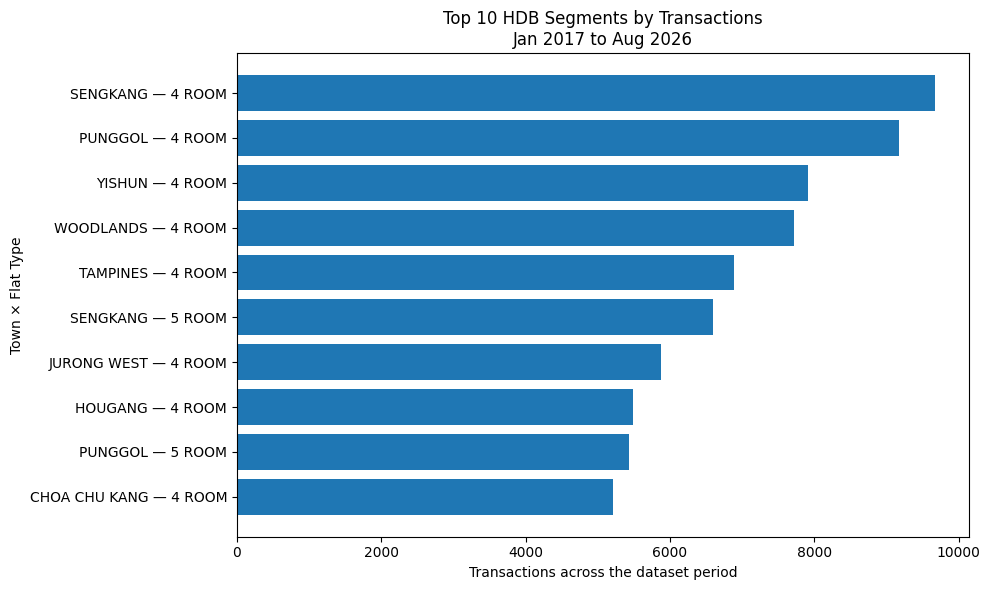

In [43]:
top10_segments = segment_analysis.sort_values("transactions_all_period", ascending=False).head(10)
period_label = f'{df["month"].min():%b %Y} to {df["month"].max():%b %Y}'
plt.figure(figsize=(10, 6))
plt.barh(top10_segments["segment"], top10_segments["transactions_all_period"])
plt.gca().invert_yaxis()
plt.title(f"Top 10 HDB Segments by Transactions\n{period_label}")
plt.xlabel("Transactions across the dataset period")
plt.ylabel("Town × Flat Type")
plt.tight_layout()
plt.show()


## 11. Export validated tables

In [44]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
segment_analysis.to_csv(OUTPUT_DIR / "hdb_segment_analysis_all.csv", index=False)
segment_analysis_filtered.to_csv(OUTPUT_DIR / "hdb_segment_analysis_filtered.csv", index=False)
print("Saved tables to:", OUTPUT_DIR.resolve())


Saved tables to: /Users/sney/Projects/singapore-hdb-market-analytics/outputs
